In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

import numpy as np
import torch
torch.set_float32_matmul_precision("high")

import clip
from PIL import Image
import matplotlib.pyplot as plt
import shapiq

import src

In [2]:
# ── OpenAI CLIP adapter ────────────────────────────────────────────────
# ImageImputerFactory expects a HuggingFace-like model and processor.
# Official OpenAI CLIP ResNet models expose model(image, text_tokens) instead,
# so these adapters bridge the gap for CNN backbones.

class OpenAIClipBatch(dict):
    """Small BatchEncoding-like dict with a .tokens() helper for plotting."""

    def tokens(self):
        n_text_players = int(self["input_ids"].shape[1]) - 2
        return ["<s>"] + [f"tok_{i}" for i in range(n_text_players)] + ["</s>"]


class OpenAICLIPProcessorAdapter:
    """Processor adapter that returns pixel_values, input_ids, and attention_mask.

    Supports HF-style split calls: processor(images=...) or processor(text=...).
    """

    DUMMY_TEXT = "a"
    DUMMY_IMG = None

    def __init__(self, preprocess, context_length=77):
        self.preprocess = preprocess
        self.context_length = int(context_length)
        self.image_processor = SimpleNamespace(
            image_mean=(0.48145466, 0.4578275, 0.40821073),
            image_std=(0.26862954, 0.26130258, 0.27577711),
        )

    @staticmethod
    def _as_list(value):
        if isinstance(value, (list, tuple)):
            return list(value)
        return [value]

    def __call__(self, images=None, text=None, return_tensors="pt", padding=True, max_length=None):
        # Handle split calls from GradientGuidedSegmenter (images-only or text-only)
        if images is None and text is None:
            raise ValueError("At least one of images/text must be provided.")
        if images is None:
            images = self._as_list(self.DUMMY_IMG if self.DUMMY_IMG is not None else Image.new("RGB", (224, 224)))
        else:
            images = self._as_list(images)
        if text is None:
            text = self._as_list(self.DUMMY_TEXT)
        else:
            text = self._as_list(text)

        pixel_values = torch.stack([
            self.preprocess(img.convert("RGB") if hasattr(img, "convert") else Image.fromarray(np.asarray(img)).convert("RGB"))
            for img in images
        ])

        full_tokens = clip.tokenize(text, context_length=self.context_length, truncate=True)
        lengths = []
        for row in full_tokens:
            nonzero = torch.nonzero(row, as_tuple=False).flatten()
            lengths.append(int(nonzero[-1].item()) + 1 if len(nonzero) else 2)
        short_len = max(lengths)
        input_ids = torch.zeros((len(text), short_len), dtype=torch.long)
        attention_mask = torch.zeros((len(text), short_len), dtype=torch.long)
        for i, length in enumerate(lengths):
            input_ids[i, :length] = full_tokens[i, :length]
            attention_mask[i, :length] = 1

        return OpenAIClipBatch(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )


class OpenAICLIPModelAdapter(torch.nn.Module):
    """HF-like wrapper around an official OpenAI CLIP model."""

    def __init__(self, clip_model, name_or_path):
        super().__init__()
        self.clip_model = clip_model
        self.name_or_path = name_or_path
        self.context_length = int(getattr(clip_model, "context_length", 77))
        image_size = int(getattr(clip_model.visual, "input_resolution", 224))

        self.config = SimpleNamespace(
            model_type="clip",
            vision_config=SimpleNamespace(image_size=image_size, num_channels=3),
        )
        # CNN-style signal for ImageImputerFactory: no embeddings.patch_size.
        self.vision_model = SimpleNamespace()

    def forward(self, pixel_values, input_ids, attention_mask):
        token_ids = input_ids.clone()
        token_ids = token_ids.masked_fill(attention_mask.to(token_ids.device) == 0, 0)

        if token_ids.shape[1] < self.context_length:
            pad = torch.zeros(
                (token_ids.shape[0], self.context_length - token_ids.shape[1]),
                dtype=token_ids.dtype,
                device=token_ids.device,
            )
            token_ids = torch.cat([token_ids, pad], dim=1)
        elif token_ids.shape[1] > self.context_length:
            token_ids = token_ids[:, :self.context_length]

        logits_per_image, logits_per_text = self.clip_model(pixel_values, token_ids)
        return SimpleNamespace(
            logits_per_image=logits_per_image,
            logits_per_text=logits_per_text,
        )

### Load CNN model (RN50)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

raw_model, preprocess = clip.load("RN50", device=DEVICE, jit=False)
raw_model.eval()

model = OpenAICLIPModelAdapter(raw_model, "openai/clip-rn50").to(DEVICE).eval()
processor = OpenAICLIPProcessorAdapter(preprocess, context_length=model.context_length)

### Load data

In [4]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png")

### Build imputer with GradientGuidedSegmenter

In [5]:
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

factory = ImageImputerFactory()
imputer = factory.build(
    model, processor, input_image, input_text,
    segmenter="gradient_guided",
)
game = VisionLanguageGame(imputer, batch_size=64)
n_players_image = game.n_players_image
n_players_text = game.n_players_text
print(f"n_img={n_players_image}, n_txt={n_players_text}, layout={imputer.layout}")

n_img=35, n_txt=8, layout=SpatialLayout(n_players_image=35, n_players_text=8, image_size=224, patch_size=0, grid_size=6, n_channels=3, model_type='clip', text_total_length=10, is_stateful=False)


/home/gengtianhao/miniforge3/envs/fixlip/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1742446601637/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


### Visualize segmenter internals

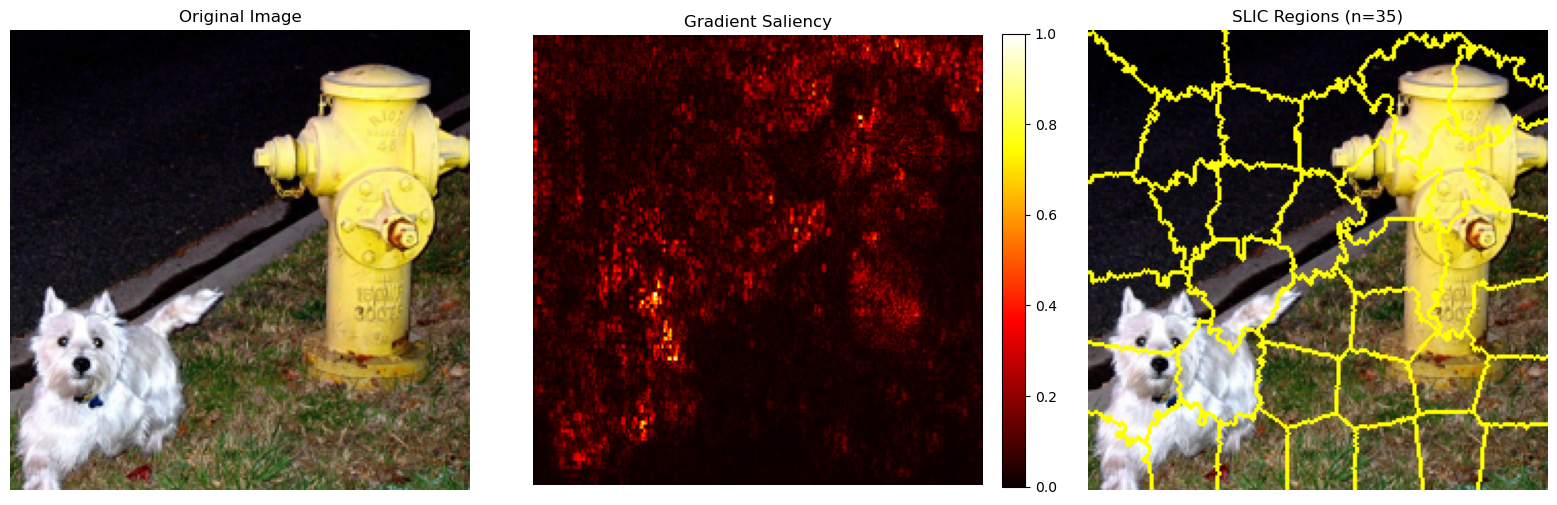

In [6]:
seg = imputer.segmenter

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Original image (denormalized)
img_denorm = src.utils.denormalize(
    game.inputs['pixel_values'].squeeze(0),
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std,
).permute(1, 2, 0).cpu().numpy()
axes[0].imshow(img_denorm)
axes[0].set_title("Original Image")
axes[0].axis("off")

# 2. Saliency map
sal = seg._saliency
im = axes[1].imshow(sal, cmap="hot", interpolation="bilinear")
axes[1].set_title(f"Gradient Saliency")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# 3. SLIC regions overlaid
from skimage.segmentation import mark_boundaries
label_map = seg._label_map.numpy() if hasattr(seg, '_label_map') else seg._region_map.numpy()
axes[2].imshow(mark_boundaries(img_denorm, label_map, mode="thick"))
axes[2].set_title(f"SLIC Regions (n={n_players_image})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Define approximator

In [7]:
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text,
    max_order=2,
    p=0.5,
    mode="banzhaf",
    random_state=0
)

### Compute explanation

In [8]:
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**18)
print(interaction_values)

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=262078,
    n_players=43, baseline_value=1.3403971227230764,
    Top 10 interactions:
        (40,): 3.0301861903519867
        (24, 36): 2.177109527868382
        (15, 41): 1.7725030508724036
        (9, 41): 1.4165758844243657
        (): 1.3403971227230764
        (19, 36): 1.1724471916782109
        (3, 41): 1.1615533852798445
        (40, 41): -1.3660924447773093
        (42,): -2.2088849385607796
        (41,): -3.2775189378880154
)


### Visualize explanation

<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'EC', 'JointSV', 'Moebius', 'k-SII', 'ELC', 'kADD-SHAP', 'SII', 'BV', 'IGV', 'BII', 'SGV', 'Co-Moebius', 'SV', 'CHGV', 'EGV', 'FSII', 'CHII', 'STII', 'FBII', 'BGV'}. This might lead to unexpected behavior.


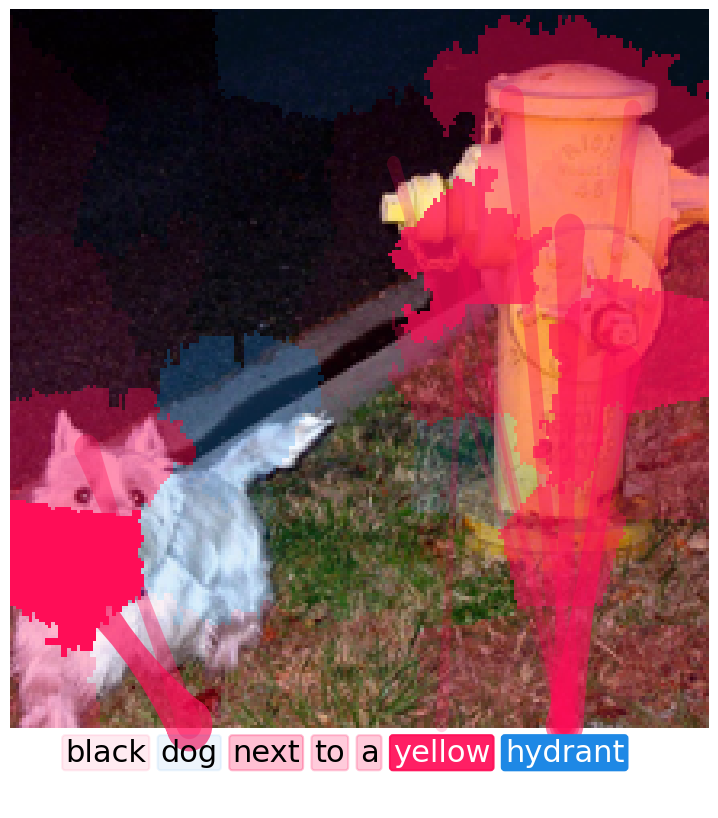

In [9]:
# ── Image + text visualization (using ImputerFactory.plot) ──
from ImputerFactory.plot import plot_image_and_text_together

text_tokens = input_text.split()
if len(text_tokens) < game.n_players_text:
    text_tokens = text_tokens + [""] * (game.n_players_text - len(text_tokens))

input_image_processed = game.inputs["pixel_values"].squeeze(0)
img_denorm = src.utils.denormalize(
    input_image_processed,
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

plot_image_and_text_together(
    img=img_denorm,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=interaction_values,
    segmenter=imputer.segmenter,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)
